# 01 · Build the world

Simulates a fictional UK ecommerce brand: **regions → calendar → demand → promotions → media budgets → impressions → clicks**.

Sales come in `02_sales_layer.ipynb`.

**Two outputs, kept apart on purpose:**

| File | Contents | Who reads it |
|---|---|---|
| `data/observed.duckdb` | what a client would send | every analysis notebook |
| `truth/truth.duckdb` | hidden parameters + clean data | only the scoring / triangulation step |

All settings live in `config/world.yaml`. The logic lives in `src/simulate/` so the geo-experiment step can re-use it later; this notebook runs it step by step and checks the result.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import duckdb
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.simulate import world, media
from src.simulate.store import write_tables

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.6, "lines.linewidth": 1.6})
COLORS = {"meta": "#2a78d6", "google_nonbrand": "#eb6834", "tiktok": "#1baf7a", "youtube_tv": "#eda100"}

cfg = yaml.safe_load((ROOT / "config/world.yaml").read_text())

# Independent random streams per component: changing one part of the world
# (e.g. media noise) doesn't reshuffle the others.
ss = np.random.SeedSequence(cfg["seed"])
rng_regions, rng_budget, rng_media = (np.random.default_rng(s) for s in ss.spawn(3))

## 1. Regions
40 UK regions. Besides population, each region gets **hidden traits** (truth only): baseline spend per head, organic growth, how strongly it responds to ads, media-buying bias, and CPM.

In [2]:
regions = world.build_regions(cfg, rng_regions)
regions.head(8).round(3)

,region_id,name,nation,population,pop_share,baseline_mult,yearly_growth,media_response_mult,cpm_mult,tv_reach_mult,alloc_meta,alloc_google_nonbrand,alloc_tiktok,alloc_brand_search
0,R01,London,England,8900000,0.412,1.487,0.006,0.796,1.398,0.932,0.946,0.913,1.054,1.000
1,R02,Birmingham,England,1140000,0.053,0.861,0.104,0.788,1.042,0.968,1.113,0.952,0.894,1.176
2,R03,Leeds,England,810000,0.037,1.098,0.058,1.055,0.953,1.073,1.102,1.105,0.924,0.795
3,R04,Glasgow,Scotland,630000,0.029,0.759,0.082,1.507,0.855,0.978,1.176,0.993,1.154,1.257
4,R05,Sheffield,England,560000,0.026,1.252,-0.022,0.814,0.884,1.115,0.877,0.952,0.933,1.019
5,R06,Manchester,England,550000,0.025,0.940,0.081,0.915,1.027,0.828,0.808,0.865,0.967,0.997
6,R07,Bradford,England,545000,0.025,1.359,0.147,0.843,0.897,0.998,0.934,0.868,0.772,1.067
7,R08,Edinburgh,Scotland,520000,0.024,0.952,0.111,0.836,0.928,0.973,1.060,0.962,1.053,1.155


## 2. Calendar and true demand
Demand = weekly pattern × yearly seasonality × events (Black Friday, Christmas, bank holidays).

`planner_forecast` is what the media planner *expects* - it drives budgets, which creates **confounding**: spend goes up exactly when sales would have gone up anyway.

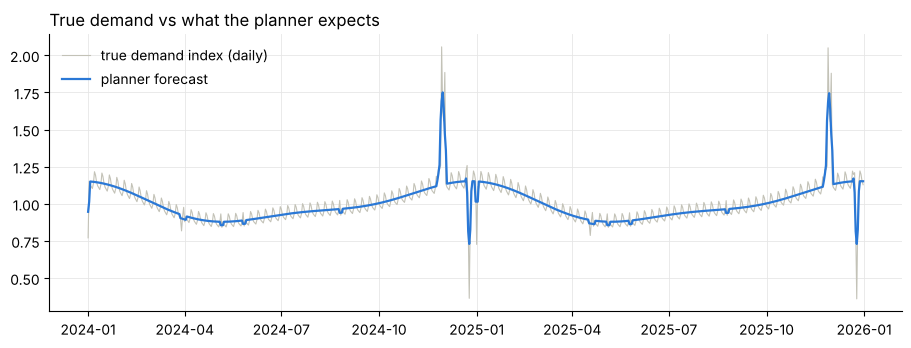

In [3]:
calendar = world.build_calendar(cfg)
demand = world.build_demand_index(cfg, calendar)

fig, ax = plt.subplots()
ax.plot(demand["date"], demand["demand_index"], color="#c3c2b7", lw=0.8, label="true demand index (daily)")
ax.plot(demand["date"], demand["planner_forecast"], color="#2a78d6", label="planner forecast")
ax.set_title("True demand vs what the planner expects", loc="left")
ax.legend(frameon=False); plt.show()

## 3. Promotions
The observed table gets dates and discount; the **true lift** stays in truth. Note the Scotland-only pop-up - a regional shock to watch for when matching geo-test markets.

In [4]:
promos = world.build_promotions(cfg, regions)
promos.groupby("promo_name").agg(start=("start_date", "first"), end=("end_date", "first"),
                                 discount=("discount", "first"), true_lift=("true_lift", "first"),
                                 n_regions=("region_id", "nunique")).sort_values("start")

,start,end,discount,true_lift,n_regions
promo_name,,,,,
spring_sale_2024,2024-03-15,2024-03-24,0.15,0.18,40
summer_sale_2024,2024-07-05,2024-07-21,0.20,0.22,40
bf_sale_2024,2024-11-25,2024-12-02,0.25,0.30,40
boxing_day_2024,2024-12-26,2025-01-05,0.30,0.25,40
spring_sale_2025,2025-03-14,2025-03-23,0.15,0.18,40
scotland_pop_up,2025-06-06,2025-06-15,0.20,0.25,5
summer_sale_2025,2025-07-04,2025-07-20,0.20,0.22,40
bf_sale_2025,2025-11-24,2025-12-01,0.25,0.30,40
boxing_day_2025,2025-12-26,2025-12-31,0.30,0.25,40


## 4. National budgets
`budget = planner_forecast^elasticity × monthly campaign shifts × day-to-day pacing noise`, scaled to the annual budget.

- TV only spends inside flighting bursts.
- **Planted problem:** TikTok copies Meta's budget shape Feb–May 2025 (collinearity).

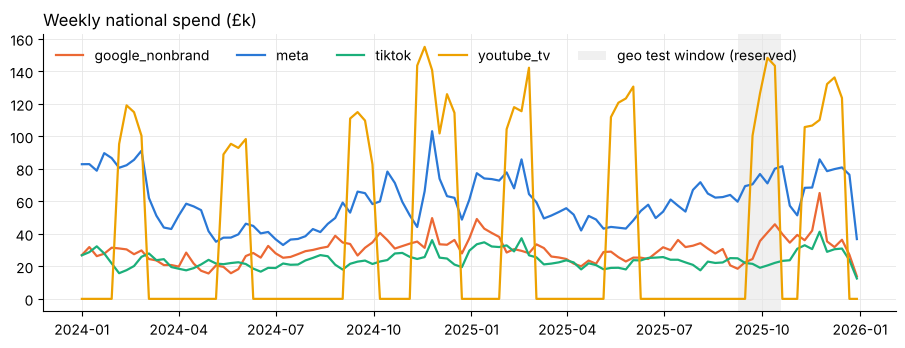

In [5]:
national_spend = media.build_national_spend(cfg, demand, rng_budget)

weekly = (national_spend.assign(week=lambda d: d["date"].dt.to_period("W").dt.start_time)
          .groupby(["week", "channel"])["spend"].sum().unstack())
fig, ax = plt.subplots()
for ch in weekly: ax.plot(weekly.index, weekly[ch] / 1e3, color=COLORS[ch], label=ch)
ax.axvspan(pd.Timestamp(cfg["geo_test_window"]["start"]), pd.Timestamp(cfg["geo_test_window"]["end"]),
           color="#e6e6e6", alpha=0.6, lw=0, label="geo test window (reserved)")
ax.set_title("Weekly national spend (£k)", loc="left"); ax.legend(frameon=False, ncol=5, loc="upper left"); plt.show()

## 5. Regional split, impressions and clicks
- Geo-targetable channels: spend split by population × buying bias × daily noise.
- YouTube/TV: bought nationally, so regions get **impressions but no spend**.
- `impressions = spend / CPM × 1000`, CPM rises with demand (Q4 auctions). `clicks ~ Binomial(impressions, CTR)`.

In [6]:
media_daily = media.build_media_daily(cfg, regions, demand, national_spend, rng_media)
media_national = media.national_rollup(media_daily, national_spend)
media_daily.sample(5, random_state=1)

,date,region_id,channel,spend,impressions,clicks,cpm,ctr
57675,2025-12-11,R36,google_nonbrand,28.604470,1275,59,22.442395,0.043415
2813,2024-03-11,R14,meta,105.236506,15895,161,6.620779,0.009554
76016,2025-03-14,R17,tiktok,37.442523,11269,78,3.322555,0.006536
27277,2025-11-12,R38,meta,70.136410,9068,103,7.734510,0.010065
28260,2025-12-07,R21,meta,171.029679,24214,270,7.063166,0.011295


## 6. Write the two databases

In [7]:
write_tables(ROOT / "truth/truth.duckdb", {
    "run_metadata": pd.DataFrame([{"seed": cfg["seed"], "config_json": json.dumps(cfg, default=str)}]),
    "region_params": regions,
    "demand_index": demand,
    "promotions_truth": promos,
    "media_daily_clean": media_daily,
    "media_national_clean": media_national,
})
write_tables(ROOT / "data/observed.duckdb", {
    "regions": world.observed_regions(regions),
    "calendar": calendar,
    "promotions": world.observed_promotions(promos),
    "media_daily": media.observed_media_daily(media_daily),
    "media_national_daily": media_national,
})
print(f"regions: {len(regions)}  days: {len(calendar)}  media rows: {len(media_daily):,}")

EXPORT_CSV = False   # set True if you also want CSV copies of the observed tables
if EXPORT_CSV:
    (ROOT / "data/csv").mkdir(exist_ok=True)
    with duckdb.connect(str(ROOT / "data/observed.duckdb"), read_only=True) as c:
        for t in c.sql("show tables").df()["name"]:
            c.sql(f"select * from {t}").df().to_csv(ROOT / f"data/csv/{t}.csv", index=False)

regions: 40  days: 731  media rows: 116,960


## 7. Sanity checks (SQL)
These are checks on the *simulator*, not the data-quality checks you'll run as the analyst later.

In [8]:
con = duckdb.connect(str(ROOT / "data/observed.duckdb"), read_only=True)
con.execute(f"ATTACH '{ROOT / 'truth/truth.duckdb'}' AS t (READ_ONLY)")
q = lambda s: con.sql(s).df()

print("Annual spend matches config (£k)")
q("""select channel, year(date) as year, round(sum(spend)/1e3) as spend_k
       from media_national_daily group by all order by 1, 2""")

Annual spend matches config (£k)


,channel,year,spend_k
0,google_nonbrand,2024,1504.0
1,google_nonbrand,2025,1650.0
2,meta,2024,3008.0
3,meta,2025,3300.0
4,tiktok,2024,1203.0
5,tiktok,2025,1320.0
6,youtube_tv,2024,2005.0
7,youtube_tv,2025,2200.0


In [9]:
print("Confounding: spend follows expected demand")
q("""select channel,
          round(corr(n.spend, d.planner_forecast), 2) as corr_with_forecast,
          round(stddev(n.spend) / avg(n.spend), 2)    as coef_of_variation
       from media_national_daily n join t.demand_index d using (date)
       group by 1 order by 1""")

Confounding: spend follows expected demand


,channel,corr_with_forecast,coef_of_variation
0,google_nonbrand,0.73,0.28
1,meta,0.72,0.28
2,tiktok,0.68,0.22
3,youtube_tv,0.34,1.41


In [10]:
print("Planted collinearity: Meta vs TikTok")
q("""with w as (select date,
                      max(spend) filter (channel = 'meta')   as meta,
                      max(spend) filter (channel = 'tiktok') as tiktok
               from media_national_daily group by date)
       select case when date between '2025-02-01' and '2025-05-31' then 'collinear window' else 'rest' end as period,
              round(corr(meta, tiktok), 2) as corr
       from w group by 1""")

Planted collinearity: Meta vs TikTok


,period,corr
0,rest,0.40
1,collinear window,0.99


In [11]:
print("Truth leakage check: columns in observed.duckdb")
q("""select table_name, string_agg(column_name, ', ') as columns
       from information_schema.columns where table_catalog = 'observed' group by 1 order by 1""")

Truth leakage check: columns in observed.duckdb


,table_name,columns
0,calendar,"date, year, day_of_week, day_of_year, iso_week..."
1,media_daily,"date, region_id, channel, spend, impressions, ..."
2,media_national_daily,"date, channel, spend, impressions, clicks"
3,promotions,"promo_name, region_id, start_date, end_date, d..."
4,regions,"region_id, name, nation, population"


In [12]:
con.close()